# Intro: loading the models

This notebook is a minimal walkthrough of the two pretrained models used in the paper:

1. Load the fine-tuned VQGAN and DeepCrack checkpoints (auto-downloaded from Zenodo, see `checkpoints.py`).
2. Apply DeepCrack to a test image from `../pictures`.
3. Show a VQGAN reconstruction of the same image.

**Requirements**: `taming-transformers` and `deepcrack` must be importable (either `pip install`-ed, or point at a local checkout with the `TAMING_TRANSFORMERS_PATH` / `DEEPCRACK_CODE_PATH` environment variables). See the README's *Model Checkpoints* section for details.

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import sys
sys.path.append("..")  # so we can import the project modules from the repo root

import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from checkpoints import get_vqgan_checkpoint, get_deepcrack_checkpoint, VQGAN_FINETUNED_L1
from model_loading import load_vqgan_model_ckpt, load_dcmodel
from loss_functions import generate_crackprior

## Configuration

`VQGAN_CONFIG_PATH` isn't auto-downloaded (it's a small architecture config, not a weight file) — point it at your local copy.

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

VQGAN_CONFIG_PATH = "../configs/vqgan_config.yaml"
TEST_IMAGE = "../pictures/Lorrain_patch.jpg"

print("Using device:", DEVICE)

Using device: cpu


## Load the models

Both checkpoints are downloaded and cached under `./checkpoints` the first time this runs.

In [30]:
vqgan_ckpt = get_vqgan_checkpoint(VQGAN_FINETUNED_L1)
vqgan = load_vqgan_model_ckpt(VQGAN_CONFIG_PATH, vqgan_ckpt, DEVICE)
vqgan.eval()
for p in vqgan.parameters():
    p.requires_grad = False

deepcrack_ckpt = get_deepcrack_checkpoint()
deepcrack = load_dcmodel(deepcrack_ckpt, DEVICE, is_checkpoint=True)

Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips\vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
Loaded raw state_dict (no Lightning wrapper).
Missing keys: ['loss.perceptual_loss.lin0.model.1.weight', 'loss.perceptual_loss.lin1.model.1.weight', 'loss.perceptual_loss.lin2.model.1.weight', 'loss.perceptual_loss.lin3.model.1.weight', 'loss.perceptual_loss.lin4.model.1.weight']
Unexpected keys: ['loss.perceptual_loss.lin0.1.weight', 'loss.perceptual_loss.lin1.1.weight', 'loss.perceptual_loss.lin2.1.weight', 'loss.perceptual_loss.lin3.1.weight', 'loss.perceptual_loss.lin4.1.weight']
VQGAN model loaded successfully.
Loaded fine-tuned checkpoint from checkpoints\deepcrack_finetuned_synthetic_unfreeze.pth
DeepCrack loaded and frozen.


## Load the test image

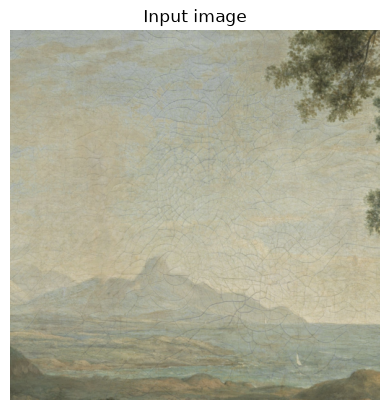

In [40]:
img_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

img_pil = Image.open(TEST_IMAGE).convert("RGB")
img = img_transform(img_pil).unsqueeze(0).to(DEVICE)  # (1,3,512,512), values in [0,1]

def to_numpy_img(t):
    return t[0].detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)

plt.imshow(to_numpy_img(img))
plt.title("Input image")
plt.axis("off")
plt.show()

## Preprocessing (LAB CLAHE)

Optional contrast enhancement from `preprocessing.py`. CLAHE applied to the L channel in LAB space, useful for low-contrast paintings (e.g. darkened varnish) before running crack detection. The rest of this notebook uses the preprocessed image.

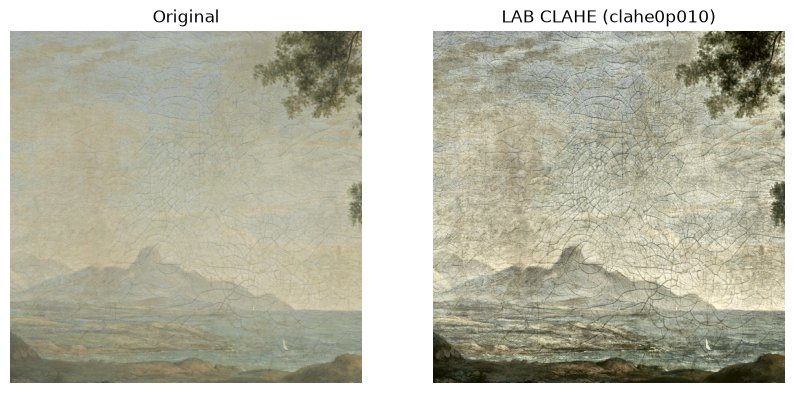

In [48]:
import numpy as np
from preprocessing import apply_preprocessing, CLIP_TAG

img_np = np.array(img_pil.resize((512, 512)))
img_np_preproc = apply_preprocessing(img_np, mode="lab_clahe")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(img_np_preproc)
axes[1].set_title(f"LAB CLAHE ({CLIP_TAG})")
axes[1].axis("off")
plt.show()

# Overwrite `img` so the rest of the notebook (DeepCrack, VQGAN) runs on the preprocessed image
img = transforms.ToTensor()(img_np_preproc).unsqueeze(0).to(DEVICE)

## Apply DeepCrack to the test image

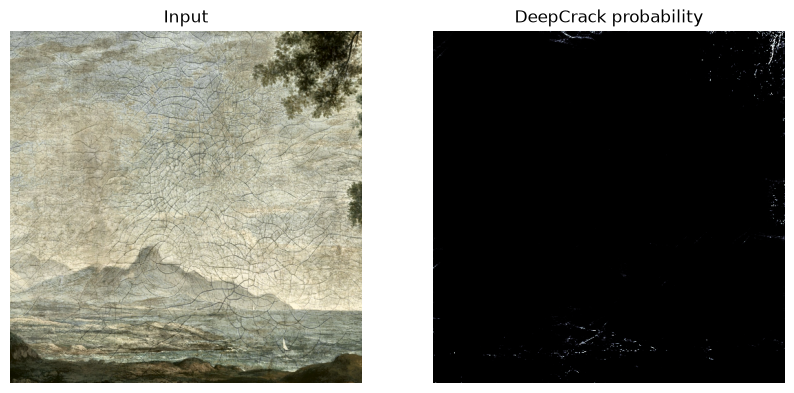

In [50]:
crack_prior = generate_crackprior(deepcrack, img)  # (1,1,512,512), crack probability in [0,1]

### Plot DeepCrack Map

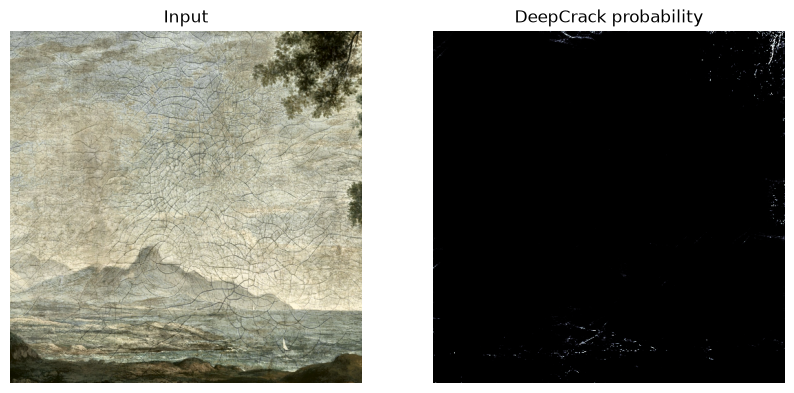

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(to_numpy_img(img))
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(crack_prior[0, 0].detach().cpu().numpy(), cmap="bone", vmin=0, vmax=1.)
axes[1].set_title("DeepCrack probability")
axes[1].axis("off")
plt.show()

## VQGAN reconstruction sample

One encode and decode pass through the fine-tuned VQGAN.

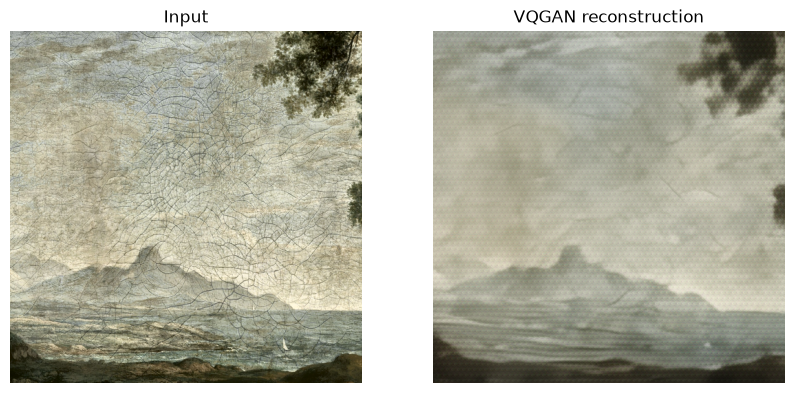

In [34]:
Y = img * 2 - 1  # VQGAN expects inputs in [-1,1]

with torch.no_grad():
    h = vqgan.encoder(Y)
    z = vqgan.quant_conv(h)
    z_q, _, _ = vqgan.quantize(z)
    Gz = vqgan.decode(z_q)

recon = (Gz.clamp(-1, 1) * 0.5 + 0.5)  # back to [0,1] for display

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(to_numpy_img(img))
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(to_numpy_img(recon))
axes[1].set_title("VQGAN reconstruction")
axes[1].axis("off")
plt.show()